In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sbaghbidi/human-faces-object-detection")
print("Path to dataset files:", path)

100%|██████████| 498M/498M [00:05<00:00, 97.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sbaghbidi/human-faces-object-detection/versions/1


In [ ]:
import os
import random
import shutil
from collections import defaultdict

import pandas as pd


CSV_PATH = path + "/faces.csv"

IMAGES_DIR = path + "/images"

OUTPUT_DIR = "dataset"


TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

SEED = 42

assert abs(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0
) < 1e-6

random.seed(SEED)


for split in ["train", "val", "test"]:

    os.makedirs(
        os.path.join(OUTPUT_DIR, "images", split),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(OUTPUT_DIR, "labels", split),
        exist_ok=True
    )


df = pd.read_csv(CSV_PATH)

grouped = defaultdict(list)

for _, row in df.iterrows():
    grouped[row["image_name"]].append(row)

all_images = list(grouped.keys())

random.shuffle(all_images)


train_end = int(len(all_images) * TRAIN_RATIO)
val_end = train_end + int(len(all_images) * VAL_RATIO)

train_images = set(all_images[:train_end])
val_images = set(all_images[train_end:val_end])
test_images = set(all_images[val_end:])


for image_name, rows in grouped.items():

    if image_name in train_images:
        split = "train"

    elif image_name in val_images:
        split = "val"

    else:
        split = "test"

    label_name = os.path.splitext(image_name)[0] + ".txt"

    label_path = os.path.join(
        OUTPUT_DIR,
        "labels",
        split,
        label_name
    )

    with open(label_path, "w") as f:

        for row in rows:

            img_w = float(row["width"])
            img_h = float(row["height"])

            x0 = float(row["x0"])
            y0 = float(row["y0"])
            x1 = float(row["x1"])
            y1 = float(row["y1"])

            x_center = ((x0 + x1) / 2) / img_w
            y_center = ((y0 + y1) / 2) / img_h

            bbox_width = (x1 - x0) / img_w
            bbox_height = (y1 - y0) / img_h

            class_id = 0

            f.write(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{bbox_width:.6f} "
                f"{bbox_height:.6f}\n"
            )

    src_image = os.path.join(IMAGES_DIR, image_name)

    dst_image = os.path.join(
        OUTPUT_DIR,
        "images",
        split,
        image_name
    )

    if os.path.exists(src_image):
        shutil.copy2(src_image, dst_image)


yaml_content = """
path: dataset

train: images/train
val: images/val
test: images/test

names:
  0: face
"""

with open("dataset/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("Done!")
print(f"Train images: {len(train_images)}")
print(f"Val images: {len(val_images)}")
print(f"Test images: {len(test_images)}")

Done!
Train images: 1542
Val images: 440
Test images: 222


In [ ]:
import shutil

shutil.make_archive(
    "dataset",
    "zip",
    "dataset"
)

'/content/dataset.zip'

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

model.train(
    data="dataset/dataset.yaml",
    epochs=30,
    imgsz=800,
    batch=8,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dfc8436f9e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

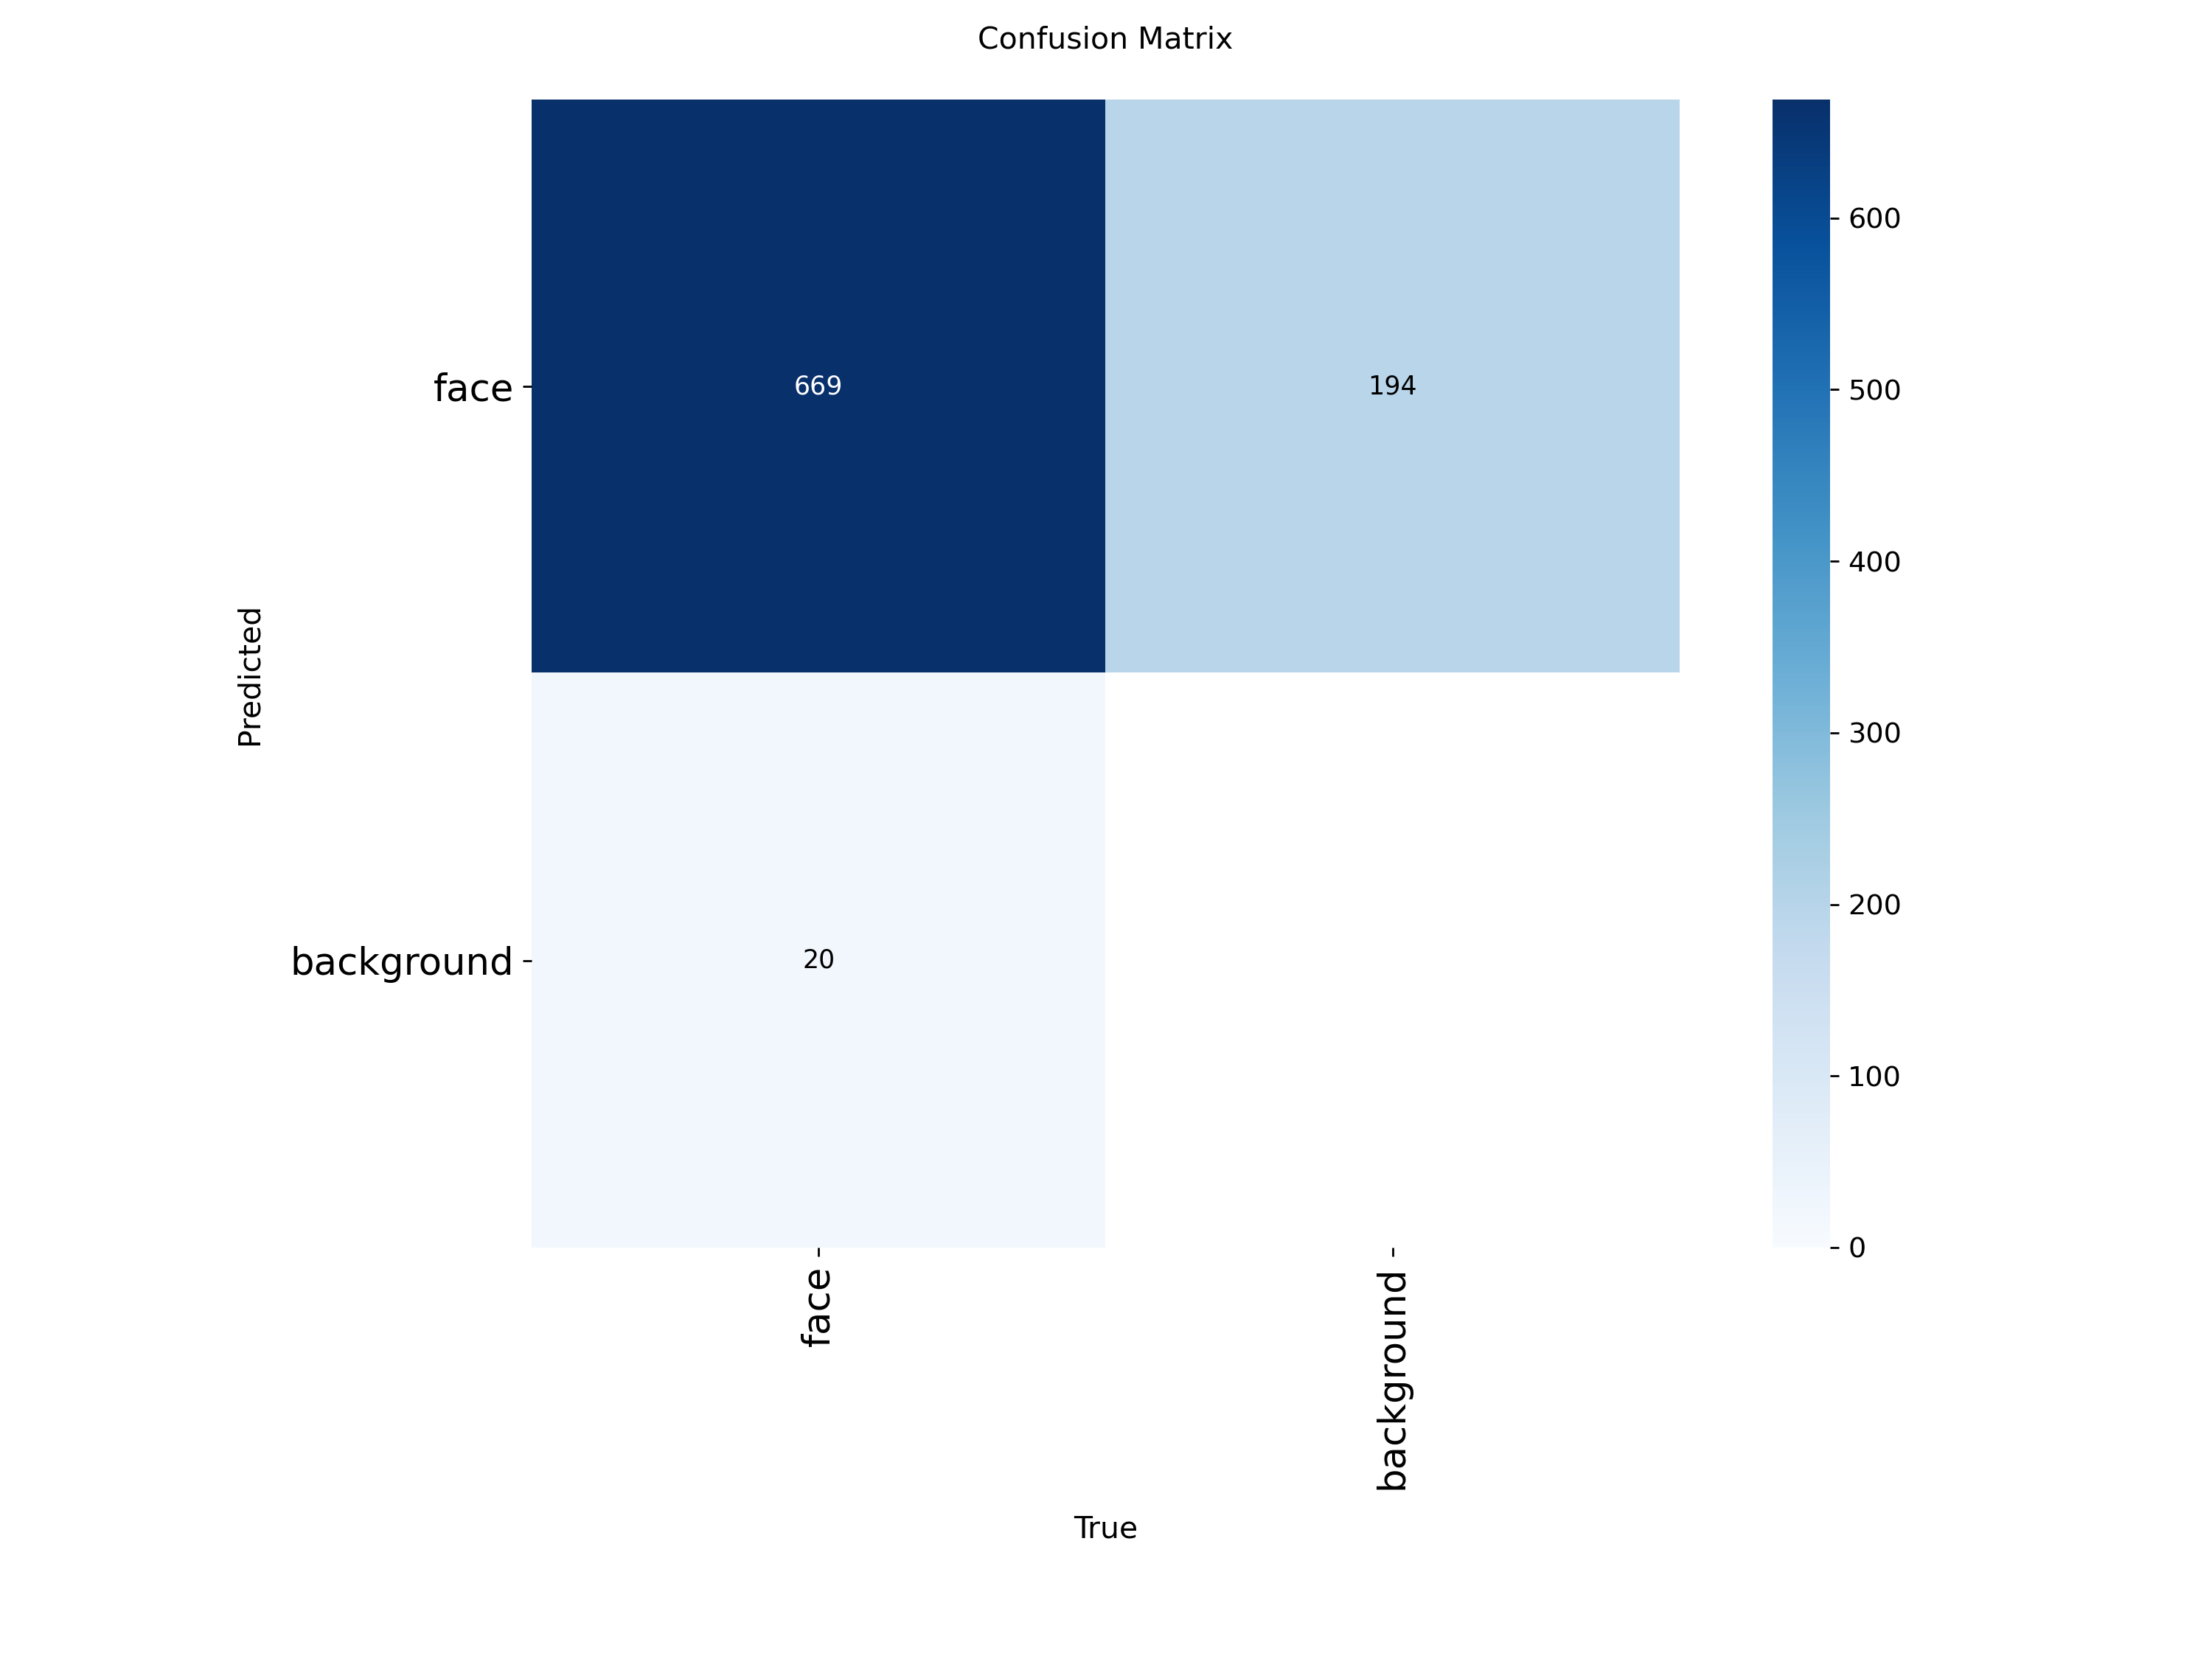

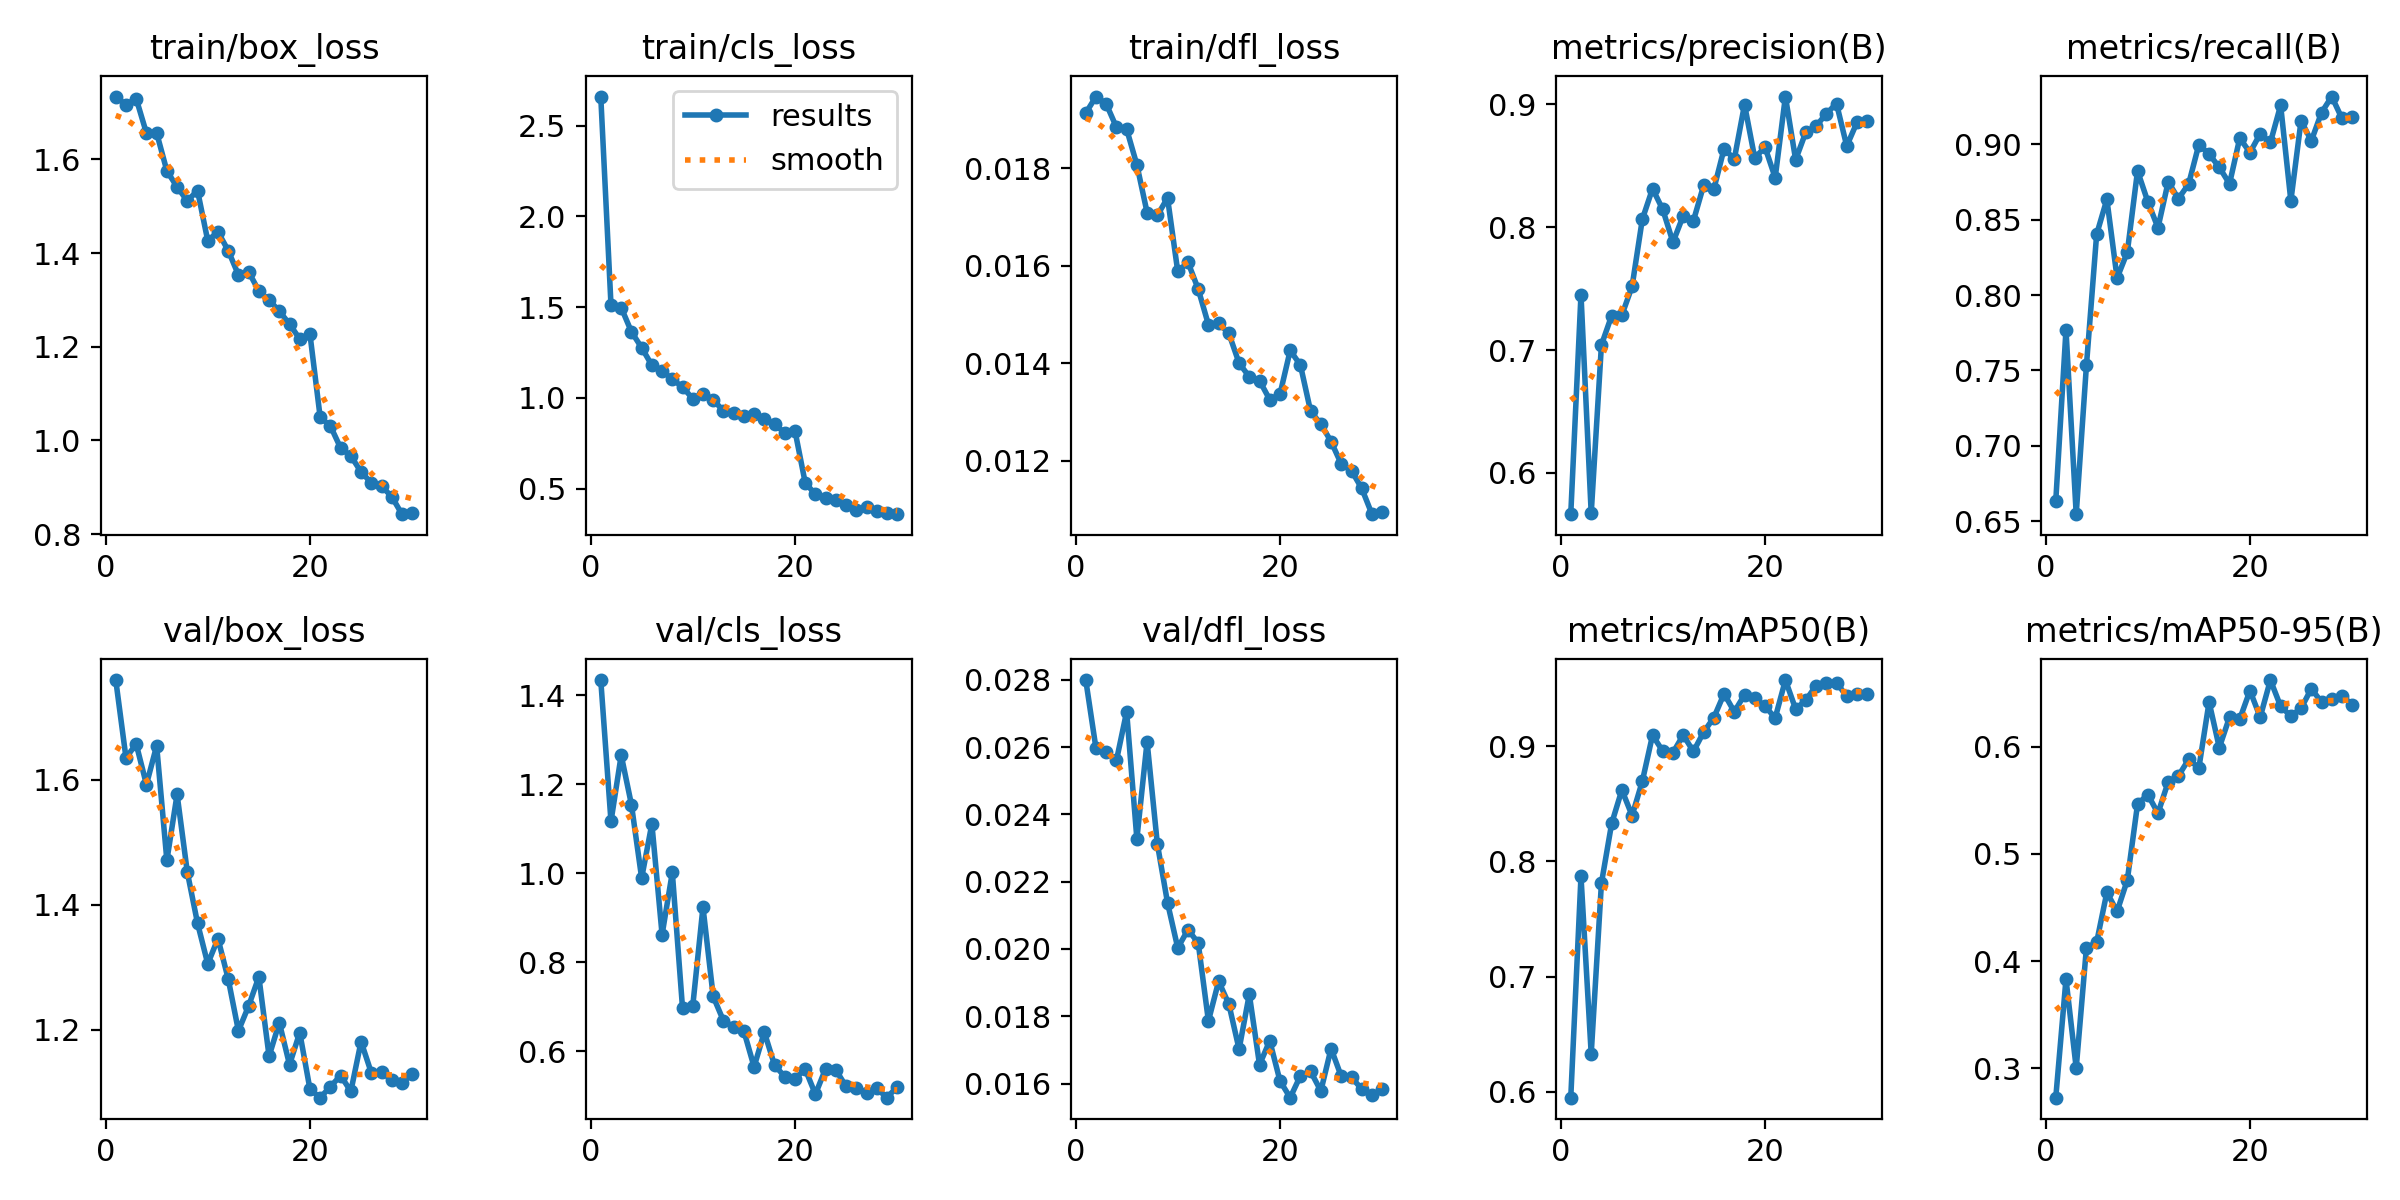